# AI-Powered Healthcare Data Integration: Anomaly Detection Across Merged Public-Health Streams

**Real data. A real integration problem. Two kinds of "anomaly" that look identical but mean opposite things.**

MedTech and public-health platforms rarely work from one clean series. They ingest
several independently-operated feeds — case surveillance, hospital capacity/EHR
census systems, lab testing networks — each with its **own reporting cadence,
latency, and failure modes** — and stitch them into one integrated view.

That stitching is where things go wrong in ways that look exactly like real
clinical events:

- A surveillance system that reports **weekly instead of daily** produces a
  sawtooth pattern that a naive detector will flag as constant "spikes."
- A hospital census feed can look perfectly smooth, and a genuine capacity
  surge shows up as a real statistical outlier in that smooth signal.
- If hospitalizations suddenly stop tracking case trends, that can mean
  either **a data pipeline broke**, or **a new variant is genuinely more/less
  severe** — and telling those apart is exactly the kind of judgment an
  integrated AI monitoring layer needs to support, not replace.

**Dataset:** [Our World in Data COVID-19 dataset](https://github.com/owid/covid-19-data)
(public, updated from official sources including CDC and JHU), filtered to the
United States, **daily, July 2020 – April 2024** (~1,380 days). We treat three
of its columns as three separate integrated feeds:

| Feed | Column | Source type | Cadence in this data |
|---|---|---|---|
| Case surveillance | `new_cases` / `new_cases_smoothed` | public-health case reporting | irregular / weekly-batched |
| Hospital capacity | `hosp_patients`, `icu_patients` | hospital census (EHR-derived) | daily, continuous |
| Lab testing | `positive_rate` | testing network | daily, gaps |

**What we'll build:**
1. Load the merged multi-source dataset
2. Spot a **data-integration artifact** hiding in the case-surveillance feed (not a clinical anomaly)
3. Detect genuine **clinical anomalies** in the clean hospital-census feed (STL + rolling z-score)
4. Build a **cross-source consistency check** — the actual integration payoff: flag days where hospitalizations decouple from the case-trend that should predict them
5. Visualize everything together and draw the line between "fix your pipeline" and "call the clinical team"


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.seasonal import STL

plt.rcParams['figure.figsize'] = (13, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', 20)


## 1. Load the merged data

One CSV here stands in for what would normally be a join across three separate
systems. We pull it straight from the public OWID GitHub repo (~94 MB, so this
cell takes a little while), then slice out the United States and the columns
that represent our three feeds.

In [2]:
URL = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"

raw = pd.read_csv(URL, low_memory=False)
us = raw[raw['location'] == 'United States'].copy()
us['date'] = pd.to_datetime(us['date'])

cols = ['date', 'new_cases', 'new_cases_smoothed', 'new_deaths',
        'hosp_patients', 'icu_patients', 'positive_rate']
df = us[cols].set_index('date').sort_index()

# Restrict to the window where the hospital-capacity feed has full daily coverage
df = df.loc['2020-07-15':'2024-04-25']

print(f"{len(df):,} days, {df.index.min().date()} to {df.index.max().date()}")
df.describe()

1,381 days, 2020-07-15 to 2024-04-25


,new_cases,new_cases_smoothed,new_deaths,hosp_patients,icu_patients,positive_rate
count,1.040000e+03,1040.000000,1381.000000,1381.000000,1381.000000,704.000000
mean,9.632412e+04,96539.613538,760.026792,36706.537292,7703.354815,0.079446
std,3.866942e+05,115636.229862,2742.934655,31208.716150,7674.992329,0.052779
min,0.000000e+00,11023.570000,0.000000,4633.000000,566.000000,0.020000
25%,0.000000e+00,40533.430000,0.000000,15321.000000,2044.000000,0.050000
50%,0.000000e+00,64280.000000,0.000000,26484.000000,3865.000000,0.060000
75%,0.000000e+00,107288.140000,0.000000,42200.000000,11534.000000,0.100000
max,5.650933e+06,807276.140000,23312.000000,154497.000000,28891.000000,0.290000


## 2. First look — three feeds, three different personalities

Plot all three raw feeds together. Before doing any anomaly detection, just
look at the shapes.

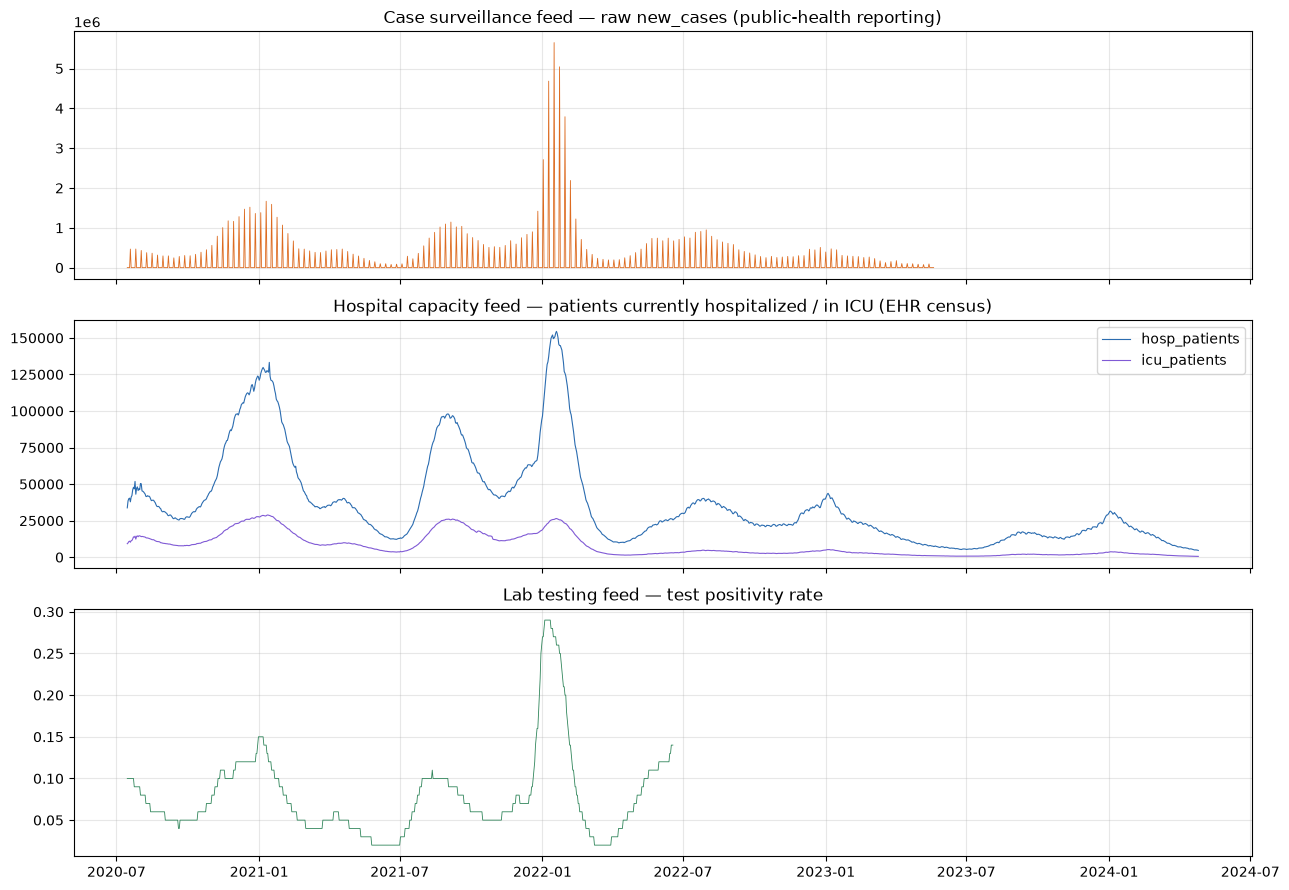

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
axes[0].plot(df.index, df['new_cases'], lw=0.6, color='#dd6b20')
axes[0].set_title("Case surveillance feed — raw new_cases (public-health reporting)")
axes[1].plot(df.index, df['hosp_patients'], lw=0.8, color='#2b6cb0')
axes[1].plot(df.index, df['icu_patients'], lw=0.8, color='#805ad5')
axes[1].set_title("Hospital capacity feed — patients currently hospitalized / in ICU (EHR census)")
axes[1].legend(['hosp_patients', 'icu_patients'], loc='upper right')
axes[2].plot(df.index, df['positive_rate'], lw=0.6, color='#2f855a')
axes[2].set_title("Lab testing feed — test positivity rate")
plt.tight_layout()
plt.show()

## 3. Data-integration artifact #1: the case feed isn't actually daily

Zoom into a few weeks of `new_cases`. It isn't noisy — it's **structurally
sawtoothed**: near-zero for six days, then one huge dump.

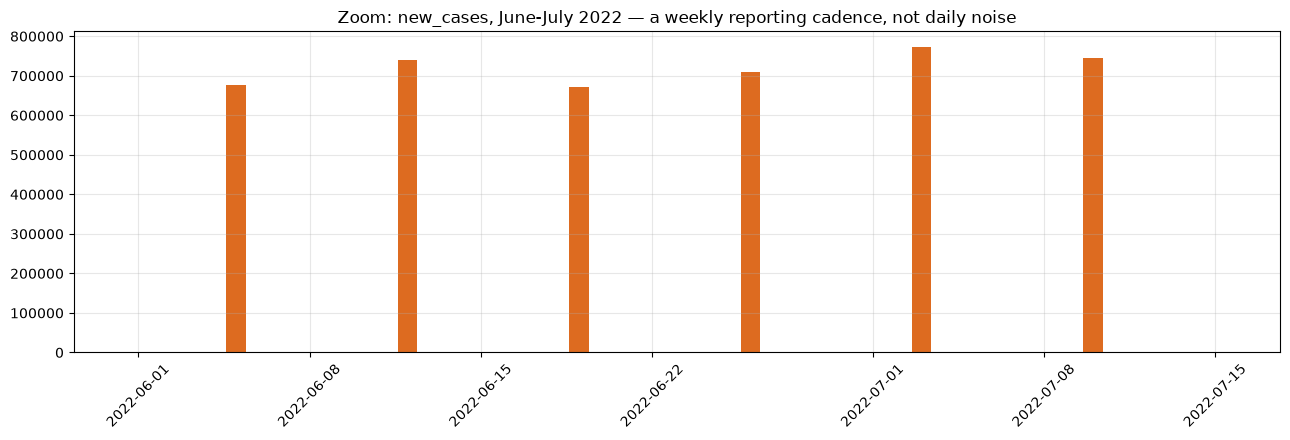

Fraction of days with exactly zero new_cases reported: 64.6%


In [4]:
zoom = df.loc['2022-06-01':'2022-07-15']
fig, ax = plt.subplots()
ax.bar(zoom.index, zoom['new_cases'], width=0.8, color='#dd6b20')
ax.set_title("Zoom: new_cases, June-July 2022 — a weekly reporting cadence, not daily noise")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Fraction of days with exactly zero new_cases reported:",
      f"{(df['new_cases'] == 0).mean():.1%}")

**This is the trap.** Feed it straight into a z-score or Isolation Forest and
*every single reporting day* gets flagged as a massive anomaly — hundreds of
false alerts a year, all meaning the same non-event: "Tuesday is batch day."

A real integration layer needs to detect and neutralize this *before*
anomaly detection runs, not after. A simple, robust signature: the series is
flat (unchanged) for many consecutive days, then jumps.

In [5]:
def flag_stale_then_jump(series, min_flat_days=5):
    # Flag the *jump* day that follows a run of >= min_flat_days unchanged values --
    # the signature of a batched/backlogged upstream feed rather than a real spike.
    unchanged = series.diff().eq(0)
    run_length = unchanged.groupby((~unchanged).cumsum()).cumcount()
    # the day AFTER a long flat run, where the value changes, is the batch dump
    is_jump = (~unchanged) & (run_length.shift(1) >= min_flat_days)
    return series.index[is_jump.fillna(False)]

cadence_artifacts = flag_stale_then_jump(df['new_cases'])
print(f"{len(cadence_artifacts)} days flagged as reporting-cadence artifacts "
      f"(batched dumps), out of {len(df)} total days")
print("These should be routed to a 'data quality' queue, not a clinical alert.")
print("Sample dates:", [d.date().isoformat() for d in cadence_artifacts[:8]])

148 days flagged as reporting-cadence artifacts (batched dumps), out of 1381 total days
These should be routed to a 'data quality' queue, not a clinical alert.
Sample dates: ['2020-07-26', '2020-08-02', '2020-08-09', '2020-08-16', '2020-08-23', '2020-08-30', '2020-09-06', '2020-09-13']


## 4. Genuine clinical anomalies — the clean hospital-census feed

`hosp_patients` is a **daily census count** (patients currently admitted),
not a diff-based report — it doesn't share the case feed's batching problem,
so it's the right signal for classic time-series anomaly detection. We use
two complementary techniques: STL decomposition on the **level** (period = 7,
since hospital census has a mild day-of-week discharge/admission pattern),
and a rolling z-score on the **day-over-day change** — since this series
trends smoothly, a sudden jump/drop shows up far more clearly in its first
difference than in its level.

STL residual method: 20 flagged days
Rolling z-score method: 49 flagged days
Flagged by BOTH methods: 8 days -> highest-confidence clinical anomalies


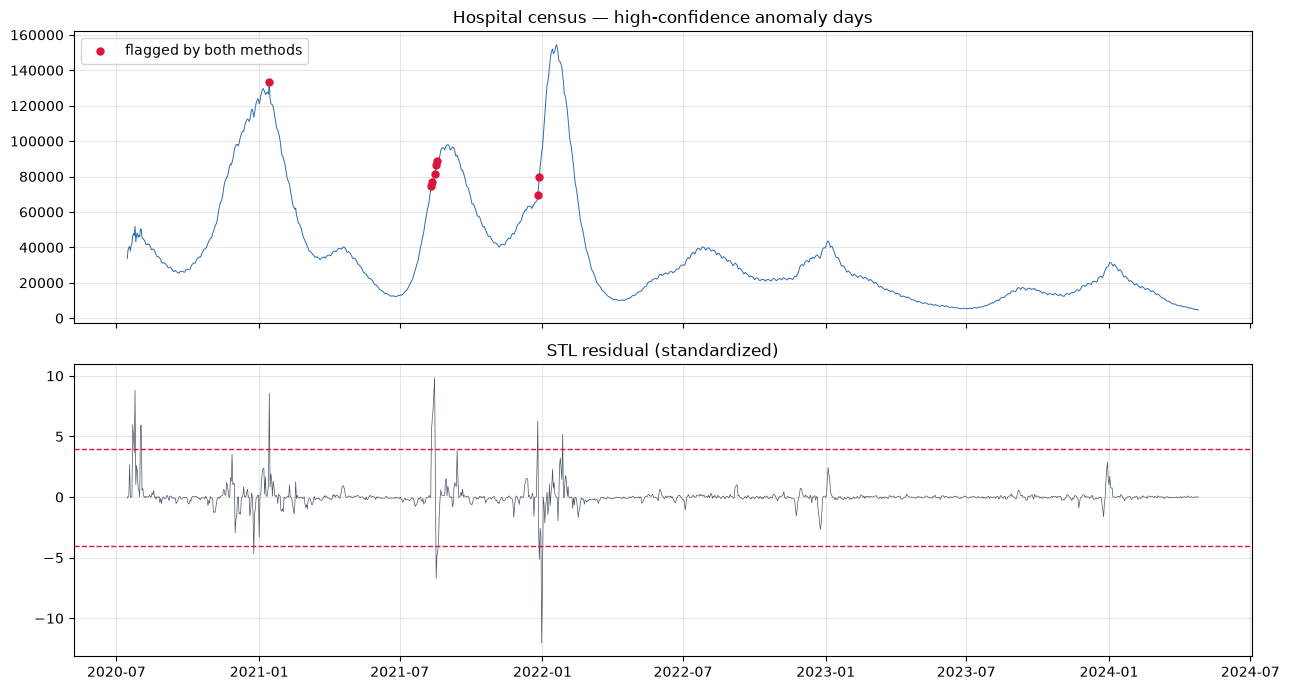

In [6]:
stl = STL(df['hosp_patients'], period=7, robust=True)
res = stl.fit()
resid = res.resid
resid_z = resid / resid.std()

STL_THRESH = 4.0
stl_anomalies = df.index[resid_z.abs() > STL_THRESH]

daily_change = df['hosp_patients'].diff()
roll_std = daily_change.rolling(21, min_periods=10).std()
z = daily_change / roll_std
Z_THRESH = 3.0
zscore_anomalies = df.index[z.abs() > Z_THRESH]

print(f"STL residual method: {len(stl_anomalies)} flagged days")
print(f"Rolling z-score method: {len(zscore_anomalies)} flagged days")
agreement = stl_anomalies.intersection(zscore_anomalies)
print(f"Flagged by BOTH methods: {len(agreement)} days -> highest-confidence clinical anomalies")

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(df.index, df['hosp_patients'], lw=0.7, color='#2b6cb0')
axes[0].scatter(agreement, df.loc[agreement, 'hosp_patients'], color='crimson', s=25, zorder=5,
                 label='flagged by both methods')
axes[0].set_title("Hospital census — high-confidence anomaly days")
axes[0].legend(loc='upper left')
axes[1].plot(df.index, resid_z, lw=0.5, color='#4a5568')
axes[1].axhline(STL_THRESH, color='crimson', ls='--', lw=1)
axes[1].axhline(-STL_THRESH, color='crimson', ls='--', lw=1)
axes[1].set_title("STL residual (standardized)")
plt.tight_layout()
plt.show()

## 5. The integration payoff: cross-source consistency

This is the check a *single* feed can never do on its own, and the reason
integration is worth the effort. Hospitalizations lag new infections by
roughly 1-2 weeks. So we build a simple expectation for today's hospital
census from the case trend ~12 days ago, and flag days where the **actual
census diverges sharply from that expectation** — in either direction.

Two very different root causes produce the same flag here:
- **Data quality**: one feed lagged, revised, or broke independently of the other.
- **Genuine clinical signal**: a new variant's severity profile shifted, so
  the historical case-to-hospitalization relationship no longer holds — which
  is itself important information, just not a pipeline bug.

Distinguishing the two is exactly the human-in-the-loop judgment call an
integrated monitoring system should surface, not silently resolve.

28 days where hospital census diverges sharply from what the 12-day-lagged case trend predicts


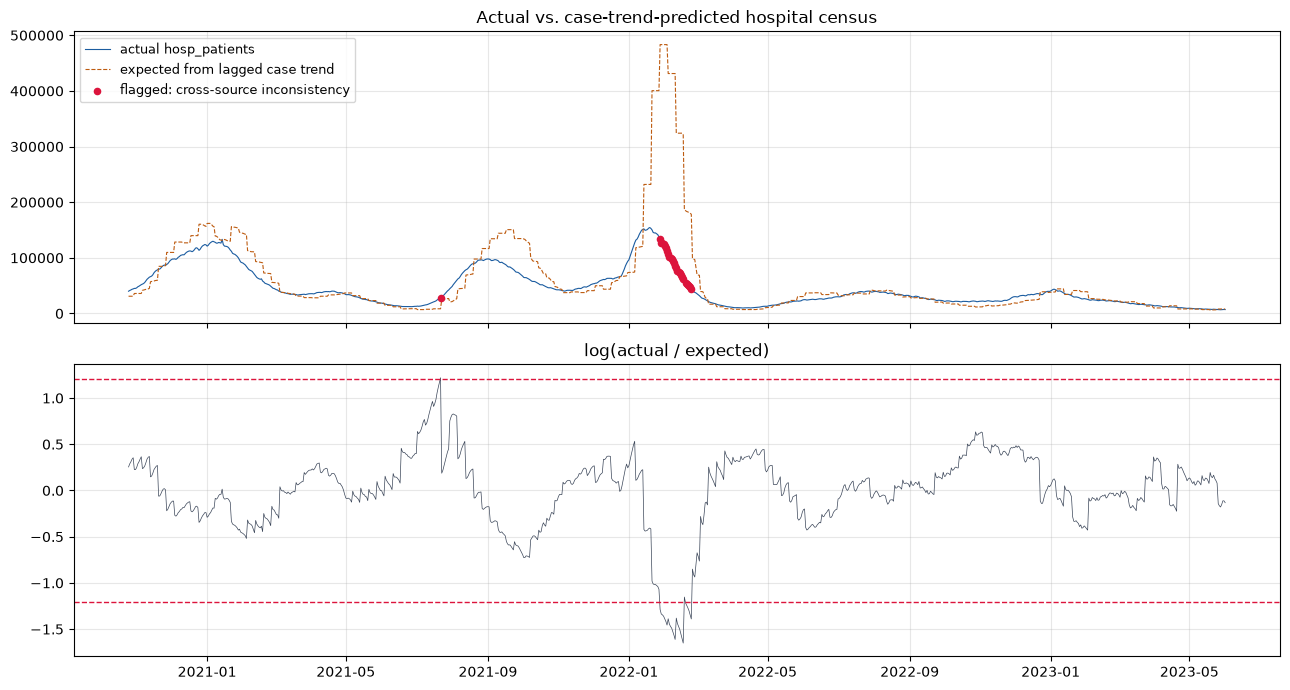

In [7]:
LAG_DAYS = 12
cases_lagged = df['new_cases_smoothed'].shift(LAG_DAYS)

# Expected hosp census as a rolling-window-fitted linear function of lagged case trend
work = pd.DataFrame({'hosp': df['hosp_patients'], 'cases_lagged': cases_lagged}).dropna()

ROLL = 90
expected = pd.Series(index=work.index, dtype=float)
for i in range(ROLL, len(work)):
    win = work.iloc[i - ROLL:i]
    # simple robust ratio-based expectation: median(hosp / cases_lagged) over the trailing window
    ratio = (win['hosp'] / win['cases_lagged'].replace(0, np.nan)).median()
    expected.iloc[i] = ratio * work['cases_lagged'].iloc[i]

consistency = pd.DataFrame({'actual': work['hosp'], 'expected': expected}).dropna()
consistency['log_ratio'] = np.log(consistency['actual'] / consistency['expected'].clip(lower=1))
CONSIST_THRESH = consistency['log_ratio'].std() * 3
inconsistent_days = consistency.index[consistency['log_ratio'].abs() > CONSIST_THRESH]

print(f"{len(inconsistent_days)} days where hospital census diverges sharply "
      f"from what the {LAG_DAYS}-day-lagged case trend predicts")

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(consistency.index, consistency['actual'], label='actual hosp_patients', color='#1b5ca0', lw=0.8)
axes[0].plot(consistency.index, consistency['expected'], label='expected from lagged case trend',
              color='#bd5b10', lw=0.8, ls='--')
axes[0].scatter(inconsistent_days, consistency.loc[inconsistent_days, 'actual'],
                 color='crimson', s=20, zorder=5, label='flagged: cross-source inconsistency')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].set_title("Actual vs. case-trend-predicted hospital census")
axes[1].plot(consistency.index, consistency['log_ratio'], lw=0.5, color='#3a4558')
axes[1].axhline(CONSIST_THRESH, color='crimson', ls='--', lw=1)
axes[1].axhline(-CONSIST_THRESH, color='crimson', ls='--', lw=1)
axes[1].set_title("log(actual / expected)")
plt.tight_layout()
plt.show()

## 6. Everything together

For context, we shade a few widely-documented pandemic waves (approximate,
for visual reference only — not a formal ground-truth label set the way NAB
provides for the taxi dataset). Note how the flags cluster: high-confidence
clinical anomalies (Section 4) and cross-source inconsistencies (Section 5)
concentrate at wave *transitions* — exactly where both real clinical shifts
and reporting-system strain are most likely to happen at once.

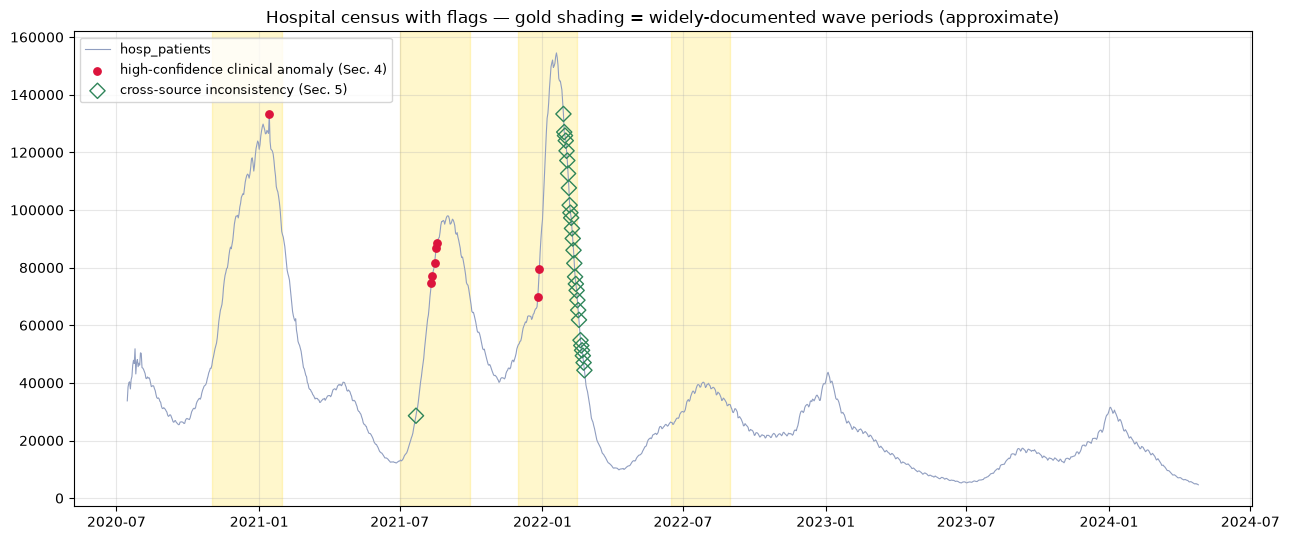

Data-integration artifacts filtered out before analysis: 148
High-confidence clinical anomalies (both univariate methods agree): 8
Cross-source consistency flags: 28


In [8]:
known_waves = {
    "Winter 2020-21": ("2020-11-01", "2021-01-31"),
    "Delta": ("2021-07-01", "2021-09-30"),
    "Omicron": ("2021-12-01", "2022-02-15"),
    "Summer 2022 (BA.5)": ("2022-06-15", "2022-08-31"),
}

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(df.index, df['hosp_patients'], lw=0.8, color='#909ec0', zorder=1, label='hosp_patients')
for name, (s, e) in known_waves.items():
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color='gold', alpha=0.2, zorder=0)
ax.scatter(agreement, df.loc[agreement, 'hosp_patients'], color='crimson', s=28, zorder=5,
           label='high-confidence clinical anomaly (Sec. 4)')
ax.scatter(inconsistent_days, consistency.loc[inconsistent_days, 'actual'], facecolors='none',
           edgecolors='#2f855a', s=60, zorder=4, marker='D', label='cross-source inconsistency (Sec. 5)')
ax.set_title("Hospital census with flags — gold shading = widely-documented wave periods (approximate)")
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Data-integration artifacts filtered out before analysis: {len(cadence_artifacts)}")
print(f"High-confidence clinical anomalies (both univariate methods agree): {len(agreement)}")
print(f"Cross-source consistency flags: {len(inconsistent_days)}")

## 7. Takeaways

- **Not every statistical outlier is a clinical event.** The case-surveillance
  feed's weekly batching produced a "spike" on *every single reporting day* —
  the single biggest source of false alarms in this whole notebook, and it
  had nothing to do with disease activity. In a real integration pipeline,
  cadence-artifact detection has to run **before** anomaly scoring, not after.
- **Pick the right feed for the job.** The hospital census feed was daily and
  structurally clean, which is exactly why classic STL/z-score methods worked
  well on it and poorly on the case feed. Feed selection is itself a modeling
  decision.
- **The real value of integration is the cross-check no single feed can do.**
  Section 5's actual-vs-expected comparison is the one output that genuinely
  needed *both* streams — and its flags are inherently ambiguous between "a
  feed broke" and "the disease's behavior changed," which is exactly the
  kind of flag that should go to a human reviewer with both hypotheses
  attached, not get auto-resolved either way.
- **This generalizes directly to MedTech systems** integrating EHR vitals,
  device telemetry, and lab results: different update cadences, different
  noise profiles, and the most valuable anomalies are the ones only visible
  once the sources are checked against each other.
